#### Name:  Jheboy B. Asid

# Laboratory Experiment # 003: Information Theory

This notebook explores the fundamental limits of communication systems as defined by Information Theory. We will analyze and visualize:

1.  **Information Measure (Entropy):** The theoretical limit of data compression.
2.  **Nyquist Capacity:** The maximum rate for a noiseless channel.
3.  **Shannon-Hartley Capacity:** The maximum rate for a noisy channel.
4.  **Eb/No Analysis:** System performance in terms of energy and noise.

**Key Libraries:**
* `numpy`: For numerical calculations and logarithmic functions.
* `matplotlib`: For visualizing relationships (Entropy curves, Capacity limits).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Configure plot style for readability
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 12

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Information Measure & Entropy

Information is measured in **bits**. The average information of a source is called **Entropy ($H$)**.

For a binary source (two possible messages) with probability $p$ and $(1-p)$, the entropy is given by:

$$H = -p \log_2(p) - (1-p) \log_2(1-p)$$

**Analysis:**
The code below calculates and plots the Entropy of a binary source as probability $p$ varies from 0 to 1. Note where the maximum entropy occurs.

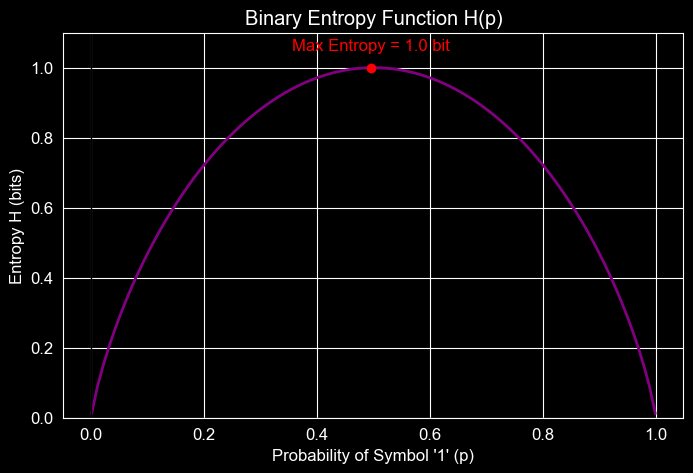

In [2]:
def plot_binary_entropy():
    """
    Plots the Entropy H(p) for a binary source (Bernoulli trial).
    """
    # 1. Define Probability Range (avoid 0 and 1 to prevent log(0) error)
    p = np.linspace(0.001, 0.999, 100)

    # 2. Calculate Entropy Formula
    # H = -p*log2(p) - (1-p)*log2(1-p)
    h = -p * np.log2(p) - (1 - p) * np.log2(1 - p)

    # 3. Plotting
    plt.figure(figsize=(8, 5))
    plt.plot(p, h, linewidth=2, color='purple')

    # Annotate Max Entropy
    max_h_idx = np.argmax(h)
    plt.plot(p[max_h_idx], h[max_h_idx], 'ro') # Mark the peak
    plt.text(p[max_h_idx], h[max_h_idx] + 0.05, f'Max Entropy = {h[max_h_idx]:.1f} bit',
             ha='center', color='red')

    plt.title("Binary Entropy Function H(p)")
    plt.xlabel("Probability of Symbol '1' (p)")
    plt.ylabel("Entropy H (bits)")
    plt.axhline(0, color='black', lw=1)
    plt.axvline(0, color='black', lw=1)
    plt.ylim(0, 1.1)
    plt.show()

# --- Exercise ---
# Run the function to visualize how uncertainty relates to probability.
plot_binary_entropy()

## 2. Nyquist Capacity (Noiseless Channel)

For an ideal **noiseless** channel, the capacity is limited by bandwidth ($B$) and the number of signaling levels ($M$).

**Formula:**
$$C = 2B \log_2 M$$

**Analysis:**
We will plot the Channel Capacity ($C$) against Bandwidth ($B$) for different modulation levels (e.g., M=2 for Binary, M=16 for 16-QAM).

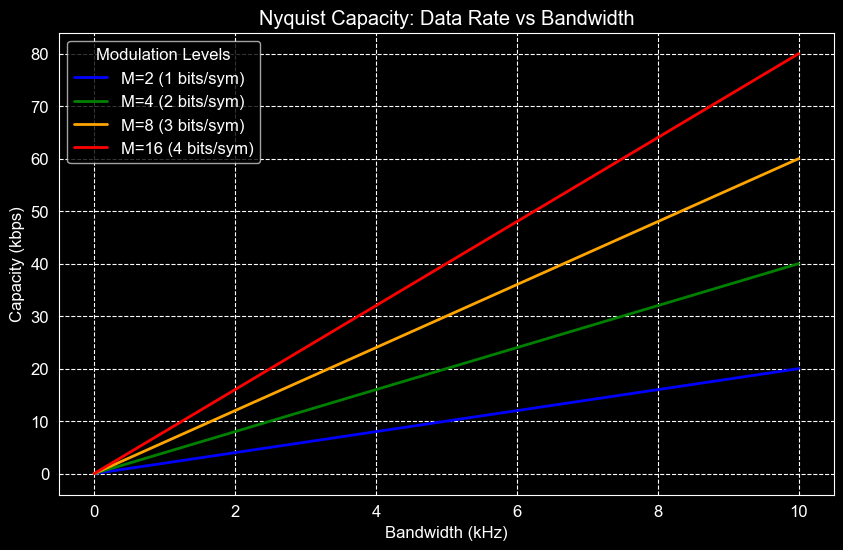

In [3]:
def plot_nyquist_capacity():
    """
    Plots Capacity vs Bandwidth for different M-ary encoding levels.
    """
    # 1. Define Bandwidth Range (e.g., 0 to 10 kHz)
    bandwidth = np.linspace(0, 10000, 100)

    # 2. Define M-levels to compare
    m_levels = [2, 4, 8, 16]
    colors = ['blue', 'green', 'orange', 'red']

    # 3. Plotting
    plt.figure(figsize=(10, 6))

    for m, color in zip(m_levels, colors):
        # C = 2 * B * log2(M)
        capacity = 2 * bandwidth * np.log2(m)

        # Convert to kbps for cleaner y-axis
        plt.plot(bandwidth/1000, capacity/1000, label=f'M={m} ({int(np.log2(m))} bits/sym)', color=color, linewidth=2)

    plt.title("Nyquist Capacity: Data Rate vs Bandwidth")
    plt.xlabel("Bandwidth (kHz)")
    plt.ylabel("Capacity (kbps)")
    plt.legend(title="Modulation Levels")
    plt.grid(True, which='both', linestyle='--')
    plt.show()

# --- Exercise ---
# Observe how increasing M (bits per symbol) increases the slope of the line.
plot_nyquist_capacity()

## 3. Shannon-Hartley Law (Noisy Channel)

In the real world, noise limits performance. Shannon's Law defines the theoretical maximum data rate ($C$) for a noisy channel.

**Formula:**
$$C = B \log_2(1 + S/N)$$

**Analysis:**
We will plot the maximum achievable Data Rate vs. Signal-to-Noise Ratio (SNR) in dB. This is the fundamental "speed limit" of the internet.

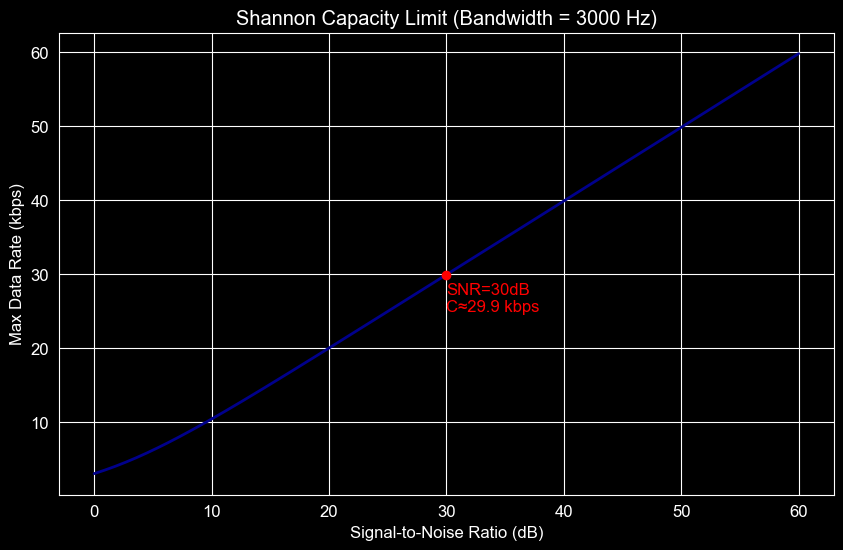

In [4]:
def plot_shannon_limit(bandwidth=3000):
    """
    Plots Capacity vs SNR (dB) for a fixed bandwidth.
    Default Bandwidth: 3000 Hz (Voice channel).
    """
    # 1. Define SNR Range in dB (e.g., 0 dB to 60 dB)
    snr_db = np.linspace(0, 60, 200)

    # 2. Convert dB to Linear Power Ratio
    # SNR_linear = 10^(SNR_dB / 10)
    snr_linear = 10 ** (snr_db / 10)

    # 3. Calculate Shannon Capacity
    # C = B * log2(1 + S/N)
    capacity = bandwidth * np.log2(1 + snr_linear)

    # 4. Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(snr_db, capacity/1000, color='darkblue', linewidth=2)

    plt.title(f"Shannon Capacity Limit (Bandwidth = {bandwidth} Hz)")
    plt.xlabel("Signal-to-Noise Ratio (dB)")
    plt.ylabel("Max Data Rate (kbps)")

    # Add marker for a typical scenario (e.g., 30 dB)
    target_snr = 30
    target_cap = bandwidth * np.log2(1 + 10**(target_snr/10)) / 1000
    plt.plot(target_snr, target_cap, 'ro')
    plt.text(target_snr, target_cap - 5, f'SNR=30dB\nC≈{target_cap:.1f} kbps', color='red')

    plt.grid(True, which="both", ls="-")
    plt.show()

# --- Exercise ---
# Run the function to see the logarithmic relationship between Power (SNR) and Speed (Capacity).
plot_shannon_limit(bandwidth=3000)

## 4. Eb/No vs. Spectral Efficiency

Often we want to compare different systems independent of bandwidth. We use **Spectral Efficiency ($C/B$)** vs **Energy per bit ($E_b/N_o$)**.

**The Shannon Limit in terms of $E_b/N_o$:**
$$\frac{C}{B} = \log_2 \left( 1 + \frac{C}{B} \cdot \frac{E_b}{N_o} \right)$$

This plot shows the "Shannon Region" (achievable) vs. the "Unachievable Region". The absolute minimum $E_b/N_o$ required for reliable communication is **-1.6 dB**.

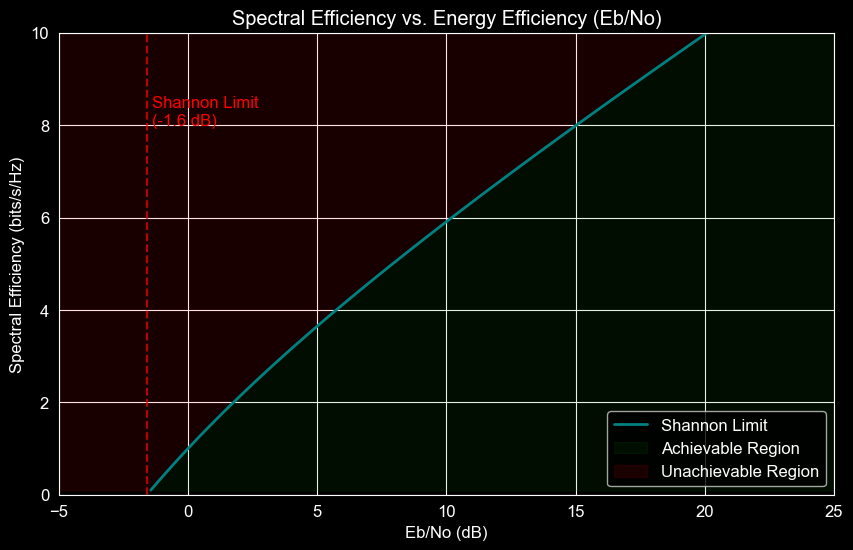

In [5]:
def plot_ebno_limit():
    """
    Plots Spectral Efficiency (C/B) vs Required Eb/No (dB).
    This is the famous 'waterfall' limit curve.
    """
    # 1. Define Spectral Efficiency range (bits/s/Hz)
    rho = np.linspace(0.1, 10, 100) # C/B

    # 2. Calculate required Eb/No (linear)
    # Formula derived from Shannon: Eb/No = (2^rho - 1) / rho
    ebno_linear = (2**rho - 1) / rho

    # 3. Convert to dB
    ebno_db = 10 * np.log10(ebno_linear)

    # 4. Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(ebno_db, rho, linewidth=2, color='teal', label='Shannon Limit')

    # Shade the regions
    plt.fill_betweenx(rho, ebno_db, 30, color='green', alpha=0.1, label='Achievable Region')
    plt.fill_betweenx(rho, -10, ebno_db, color='red', alpha=0.1, label='Unachievable Region')

    # Mark the -1.59 dB limit
    plt.axvline(-1.59, color='red', linestyle='--', alpha=0.7)
    plt.text(-1.4, 8, 'Shannon Limit\n(-1.6 dB)', color='red')

    plt.title("Spectral Efficiency vs. Energy Efficiency (Eb/No)")
    plt.xlabel("Eb/No (dB)")
    plt.ylabel("Spectral Efficiency (bits/s/Hz)")
    plt.xlim(-5, 25)
    plt.ylim(0, 10)
    plt.legend()
    plt.grid(True)
    plt.show()

# --- Exercise ---
# This plot separates what is physically possible from what is impossible.
plot_ebno_limit()